 # **Group Project 2: Rental House and Condominium Pricing in Malaysia**

  **Group 8**

In [ ]:
!pip install scikit-learn # install scikit library

**1. Problem Definition and Dataset Selection**
- **Problem Definition:** This chosen dataset contains of properties with features to predict unit/property monthly rent price in Selangor. The prediction towards the target variable `monthly_rent` is made based on other continuous and categorical features.
- **Dataset Selection:** Based on Project 1, this `mudah-apartment-kl-selangor.csv` which is the second dataset used in Project 1, shows a better quality and usability compared to the first dataset hence it is chosen for Project 2.

In [ ]:
# Load dataset
import pandas as pd
data = pd.read_csv('mudah-apartment-kl-selangor.csv')
data.head()

,ads_id,prop_name,completion_year,monthly_rent,location,property_type,rooms,parking,bathroom,size,furnished,facilities,additional_facilities,region
0,100323185,The Hipster @ Taman Desa,2022.0,RM 4 200 per month,Kuala Lumpur - Taman Desa,Condominium,5,2.0,6.0,1842 sq.ft.,Fully Furnished,"Minimart, Gymnasium, Security, Playground, Swi...","Air-Cond, Cooking Allowed, Washing Machine",Kuala Lumpur
1,100203973,Segar Courts,NaN,RM 2 300 per month,Kuala Lumpur - Cheras,Condominium,3,1.0,2.0,1170 sq.ft.,Partially Furnished,"Playground, Parking, Barbeque area, Security, ...","Air-Cond, Cooking Allowed, Near KTM/LRT",Kuala Lumpur
2,100323128,Pangsapuri Teratak Muhibbah 2,NaN,RM 1 000 per month,Kuala Lumpur - Taman Desa,Apartment,3,NaN,2.0,650 sq.ft.,Fully Furnished,"Minimart, Jogging Track, Lift, Swimming Pool",NaN,Kuala Lumpur
3,100191767,Sentul Point Suite Apartment,2020.0,RM 1 700 per month,Kuala Lumpur - Sentul,Apartment,2,1.0,2.0,743 sq.ft.,Partially Furnished,"Parking, Playground, Swimming Pool, Squash Cou...","Cooking Allowed, Near KTM/LRT, Washing Machine",Kuala Lumpur
4,97022692,Arte Mont Kiara,NaN,RM 1 299 per month,Kuala Lumpur - Mont Kiara,Service Residence,1,1.0,1.0,494 sq.ft.,Not Furnished,"Parking, Security, Lift, Swimming Pool, Playgr...",Air-Cond,Kuala Lumpur


In [ ]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
ads_id                      0
prop_name                 948
completion_year          9185
monthly_rent                2
location                    0
property_type               0
rooms                       6
parking                  5702
bathroom                    6
size                        0
furnished                   5
facilities               2209
additional_facilities    5948
region                      0
dtype: int64


**2. Data Preprocessing and Feature Engineering**

In [ ]:
def bin_monthly_rent(data):
    """
    Bins the 'monthly_rent' column into three categories: 'Low', 'Moderate', 'High'.

    Parameters:
    data (pd.DataFrame): The input DataFrame with a 'monthly_rent' column.

    Returns:
    pd.DataFrame: A DataFrame with an additional 'rent_category' and 'rent_category_encoded' columns.
    """
    data = data.copy()

    # Convert 'monthly_rent' to numerical values
    data['monthly_rent'] = data['monthly_rent'].str.extract(r'(\d+(?:,\d+)*)').replace(',', '', regex=True).astype(float)

    # Filter monthly_rent to be within the range by removing outliers
    data = data[(data['monthly_rent'] > 100) & (data['monthly_rent'] < 1000)]

    # Define bins and labels for rent categories
    bins = [100, 400, 700, 1000]  # Custom bin edges (exclusive of upper boundary)
    labels = ['Low', 'Moderate', 'High']  # Three categories

    # Apply binning
    data['rent_category'] = pd.cut(data['monthly_rent'], bins=bins, labels=labels, right=False, include_lowest=True)

    # Handle NaN (out-of-range rows) and ensure the 'Out of Range' category is included
    data['rent_category'] = data['rent_category'].astype('category')
    data['rent_category'] = data['rent_category'].cat.add_categories('Out of Range').fillna('Out of Range')

    # Encode the rent_category column
    mapping = {'Out of Range': -1, 'Low': 0, 'Moderate': 1, 'High': 2}
    data['rent_category_encoded'] = data['rent_category'].map(mapping)

    return data

In [ ]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

def preprocess_data(data):
    # Step 1: Create a copy of the data to avoid SettingWithCopyWarning
    data_subset = data.copy()

    # Step 2: Bin 'monthly_rent' into categories
    data_subset = bin_monthly_rent(data_subset)

    # Step 3: Data Cleaning for 'size' and other numerical columns
    data_subset['size'] = data_subset['size'].str.extract(r'(\d+(?:,\d+)*)').replace(',', '', regex=True).astype(float)
    data_subset['rooms'] = pd.to_numeric(data_subset['rooms'], errors='coerce')

    # Drop duplicates
    data_subset = data_subset.drop_duplicates()

    # Fill missing values for numerical columns with median
    numerical_cols = ['completion_year', 'parking', 'bathroom', 'size', 'rooms']
    for col in numerical_cols:
        if data_subset[col].isnull().sum() > 0:
            data_subset[col] = data_subset[col].fillna(data_subset[col].median())

    # Fill missing values for categorical columns with mode
    categorical_cols = ['prop_name', 'rent_category_encoded', 'furnished', 'facilities', 'additional_facilities']
    for col in categorical_cols:
        if data_subset[col].isnull().sum() > 0:
            data_subset[col] = data_subset[col].fillna(data_subset[col].mode()[0])

    # Step 4: Normalize numerical columns
    scaler = MinMaxScaler()
    data_subset[['size', 'completion_year', 'bathroom', 'parking', 'rooms']] = scaler.fit_transform(
        data_subset[['size', 'completion_year', 'bathroom', 'parking', 'rooms']]
    )

    # Step 5: One-hot encode categorical columns and Label encode 'location' and 'facilities'
    data_encoded = pd.get_dummies(data_subset, columns=['property_type', 'furnished', 'region'], drop_first=True)

    # Label encode 'location' and 'facilities'
    le = LabelEncoder()
    data_encoded['location'] = le.fit_transform(data_encoded['location'])
    data_encoded['facilities'] = le.fit_transform(data_encoded['facilities'])

    # Step 6: Feature Selection
    selected_columns = [
        'rent_category_encoded', 'size', 'completion_year', 'bathroom', 'parking', 'rooms',
        'location', 'facilities', 'property_type_Condominium', 'property_type_Service Residence',
        'furnished_Partially Furnished', 'region_Selangor'
    ]
    data_final = data_encoded[selected_columns]

    # Return the preprocessed DataFrame
    return data_final

# Usage: Apply preprocessing to the dataset
data_final = preprocess_data(data)

In [ ]:
# Check for any remaining missing values
print("Missing values per column after cleaning:")
print(data_final.isnull().sum())

# Summary of the processed data
print(data_final.info())
print(data_final.head())

Missing values per column after cleaning:
rent_category_encoded              0
size                               0
completion_year                    0
bathroom                           0
parking                            0
rooms                              0
location                           0
facilities                         0
property_type_Condominium          0
property_type_Service Residence    0
furnished_Partially Furnished      0
region_Selangor                    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 3510 entries, 77 to 19983
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   rent_category_encoded            3510 non-null   category
 1   size                             3510 non-null   float64 
 2   completion_year                  3510 non-null   float64 
 3   bathroom                         3510 non-null   float64 
 4   parking       

In [ ]:
# Save the preprocessed data to a new CSV file
data_final.to_csv('/content/preprocessed_apartment_data.csv', index=False)

**3. Baseline Models**


Model: Logistic Regression
Accuracy: 0.7892
Precision: 0.7283
Recall: 0.7892
F1 Score: 0.7005
Confusion Matrix:
 [[  0   0  34]
 [  0   2 185]
 [  0   3 829]]


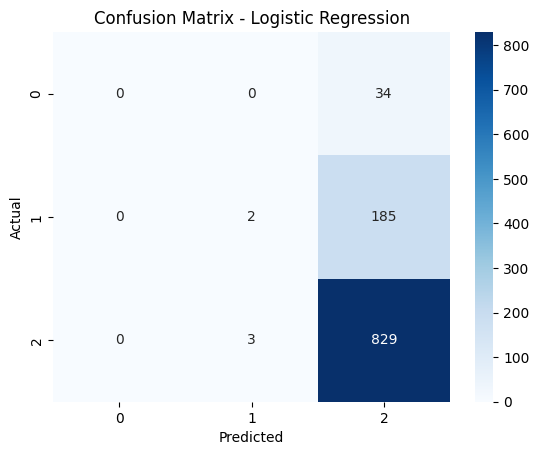


Model: Linear Discriminant Analysis
Accuracy: 0.7863
Precision: 0.7520
Recall: 0.7863
F1 Score: 0.7393
Confusion Matrix:
 [[  0   7  27]
 [  0  33 154]
 [  0  37 795]]


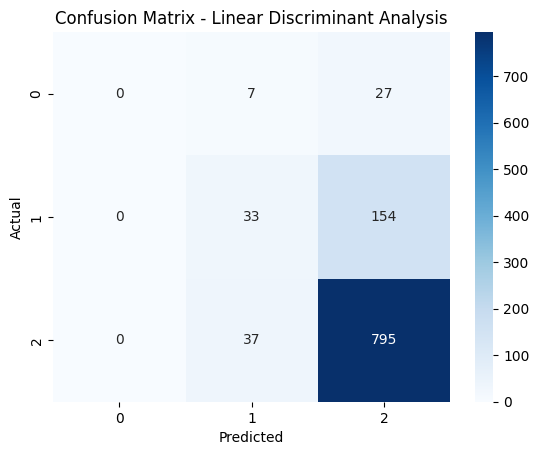


Model: k-Nearest Neighbors
Accuracy: 0.7892
Precision: 0.7547
Recall: 0.7892
F1 Score: 0.7672
Confusion Matrix:
 [[  1   6  27]
 [  0  67 120]
 [  5  64 763]]


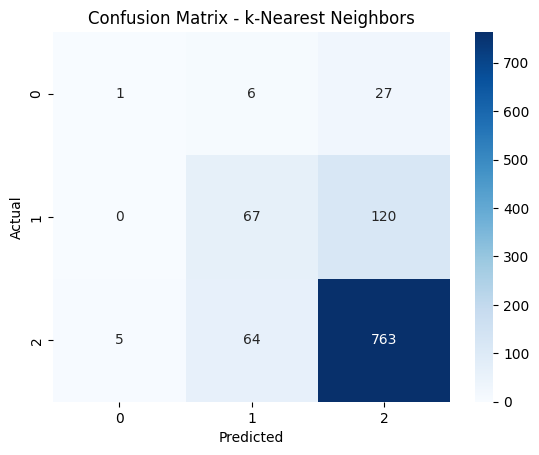


Model: Decision Tree
Accuracy: 0.7816
Precision: 0.7912
Recall: 0.7816
F1 Score: 0.7847
Confusion Matrix:
 [[  7  11  16]
 [  3 106  78]
 [ 10 112 710]]


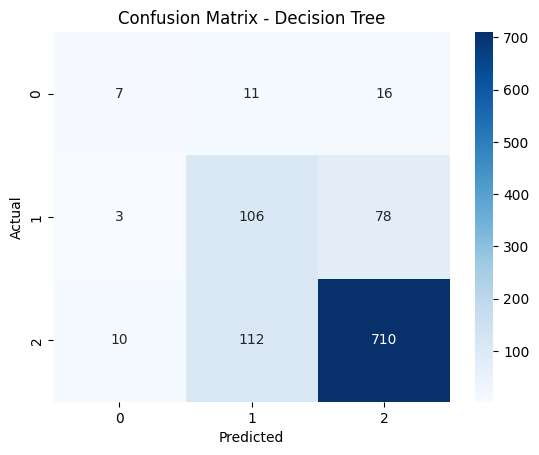


Model: Naive Bayes
Accuracy: 0.7360
Precision: 0.7093
Recall: 0.7360
F1 Score: 0.7192
Confusion Matrix:
 [[  6   2  26]
 [ 16  37 134]
 [ 23  77 732]]


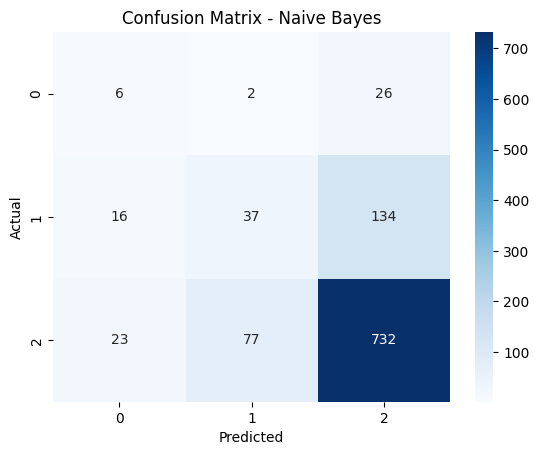


Model: Support Vector Machine
Accuracy: 0.7901
Precision: 0.8342
Recall: 0.7901
F1 Score: 0.6975
Confusion Matrix:
 [[  0   0  34]
 [  0   0 187]
 [  0   0 832]]


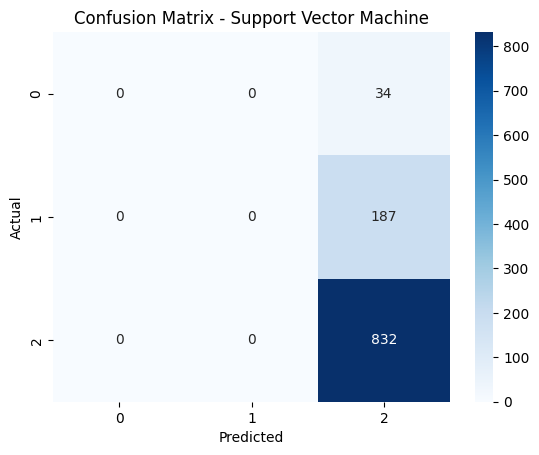

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import seaborn as sns
import matplotlib.pyplot as plt

# Load the preprocessed dataset
data_final = pd.read_csv('/content/preprocessed_apartment_data.csv')

# Define target and features
X = data_final.drop('rent_category_encoded', axis=1)  # Assuming 'rent_category_encoded' is the target
y = data_final['rent_category_encoded']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, solver='liblinear'),  # Increased max_iter and changed solver
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "k-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC()
}

# Evaluate models
for name, model in models.items():
    print(f"\nModel: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", conf_matrix)

    # Visualize confusion matrix
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


**4. Improve Model Accuracy with Ensembles and Bossting**


Model: Bagged Decision Trees
Accuracy: 0.8272
Precision: 0.8213
Recall: 0.8272
F1 Score: 0.8231
Confusion Matrix:
 [[  8  10  16]
 [  3 109  75]
 [  7  71 754]]


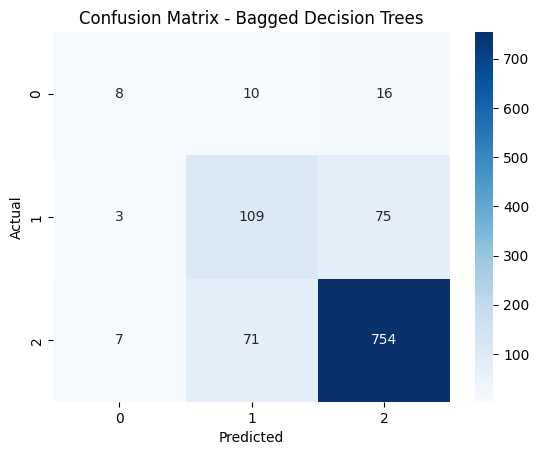


Model: Random Forest
Accuracy: 0.8300
Precision: 0.8141
Recall: 0.8300
F1 Score: 0.8139
Confusion Matrix:
 [[  3   7  24]
 [  0  93  94]
 [  2  52 778]]


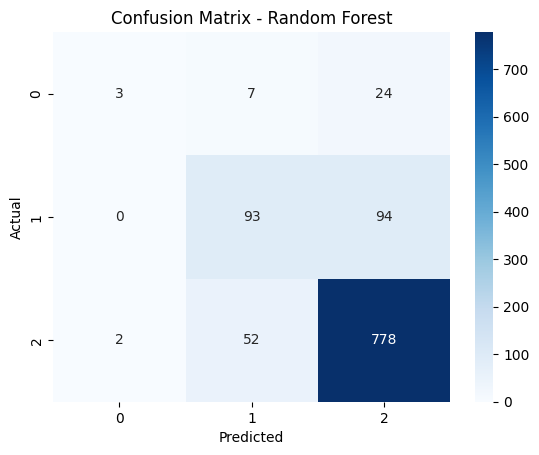


Model: Extra Trees
Accuracy: 0.8196
Precision: 0.8029
Recall: 0.8196
F1 Score: 0.8093
Confusion Matrix:
 [[  3   6  25]
 [  0 102  85]
 [  8  66 758]]


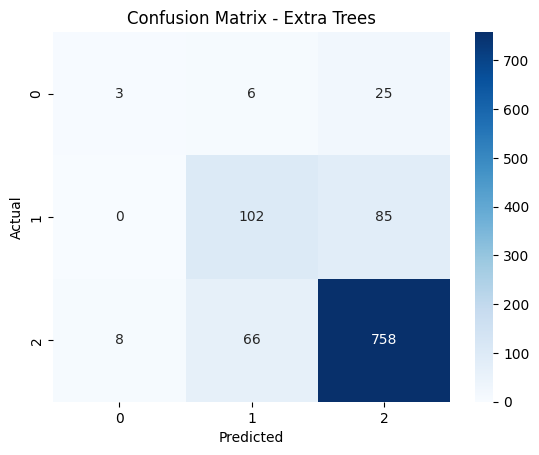


Model: AdaBoost
Accuracy: 0.7939
Precision: 0.7569
Recall: 0.7939
F1 Score: 0.7168
Confusion Matrix:
 [[  0   3  31]
 [  0  10 177]
 [  0   6 826]]


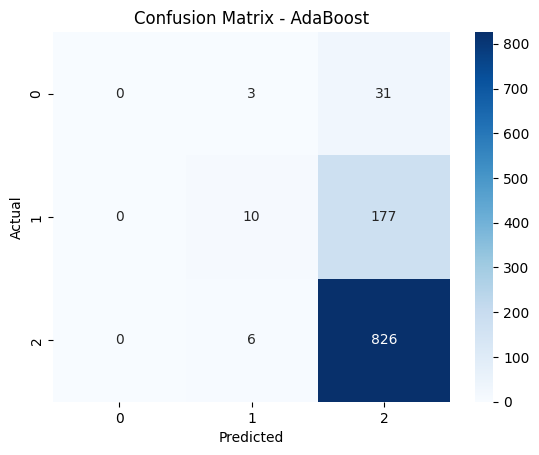


Model: Gradient Boosting
Accuracy: 0.8158
Precision: 0.7861
Recall: 0.8158
F1 Score: 0.7941
Confusion Matrix:
 [[  3   8  23]
 [  6  70 111]
 [  4  42 786]]


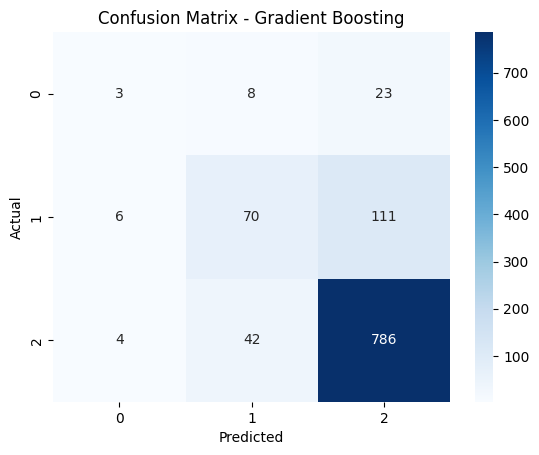

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Tuned Random Forest - Evaluation Metrics
Accuracy: 0.8158
Precision: 0.7861
Recall: 0.8158
F1 Score: 0.7941
Confusion Matrix:
 [[  3   8  23]
 [  6  70 111]
 [  4  42 786]]


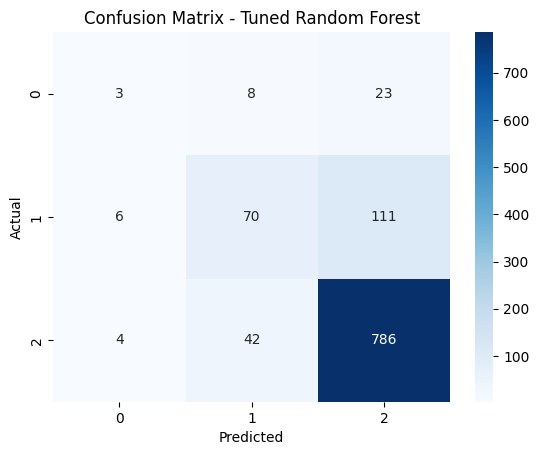

In [ ]:
# Improve Model Accuracy with Ensembles and Boosting

import pandas as pd
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load the preprocessed dataset
data_final = pd.read_csv('/content/preprocessed_apartment_data.csv')

# Define target and features
X = data_final.drop('rent_category_encoded', axis=1)  # Assuming 'rent_category_encoded' is the target
y = data_final['rent_category_encoded']

# Split the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Ensemble Methods
ensemble_models = {
    "Bagged Decision Trees": BaggingClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier()
}

# Boosting Algorithms
boosting_models = {
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Combine all models for evaluation
all_models = {**ensemble_models, **boosting_models}

# Evaluate each model
for name, model in all_models.items():
    print(f"\nModel: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", conf_matrix)

    # Visualize confusion matrix
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Parameter Tuning (Optional)
# Example for Grid Search on Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Display the best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Evaluate the tuned model
y_pred_tuned = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nTuned Random Forest - Evaluation Metrics")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**5. Model Comparison**

Comparative Analysis Results
                       Model  Accuracy  Precision   Recall  F1-Score
               Random Forest  0.828110   0.808328 0.828110  0.812633
           Gradient Boosting  0.818613   0.789903 0.818613  0.797269
                 Extra Trees  0.812915   0.793859 0.812915  0.801686
       Bagged Decision Trees  0.808167   0.804130 0.808167  0.804432
                    AdaBoost  0.793922   0.756938 0.793922  0.716751
      Support Vector Machine  0.790123   0.834172 0.790123  0.697488
         Logistic Regression  0.789174   0.746252 0.789174  0.714524
         k-Nearest Neighbors  0.789174   0.754719 0.789174  0.767213
Linear Discriminant Analysis  0.786325   0.751992 0.786325  0.739251
               Decision Tree  0.777778   0.789916 0.777778  0.782435
                 Naive Bayes  0.735992   0.709347 0.735992  0.719239


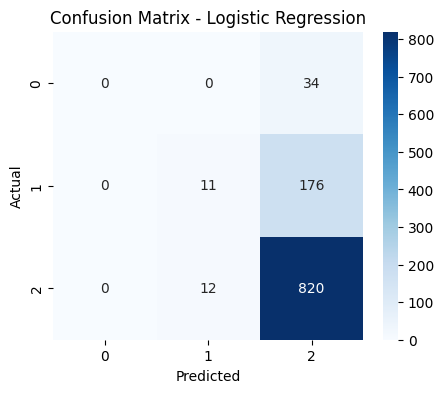

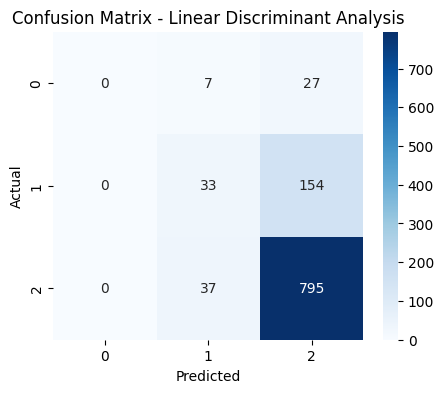

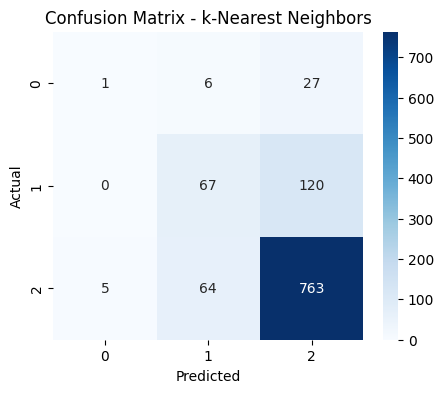

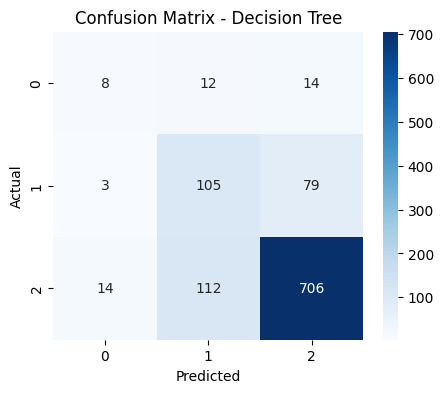

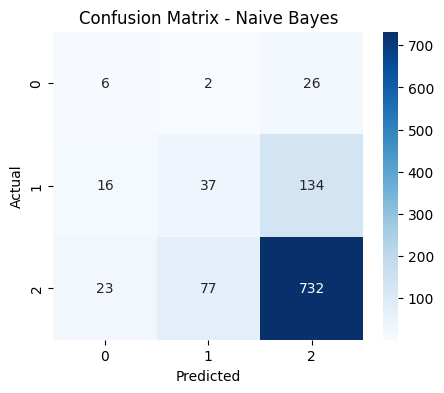

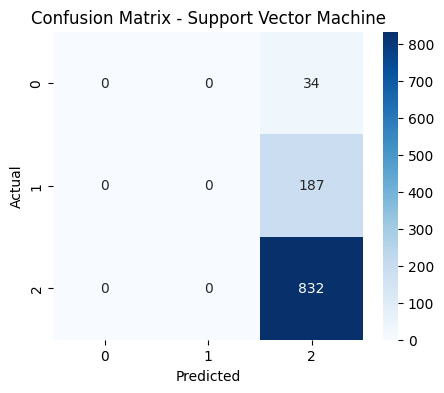

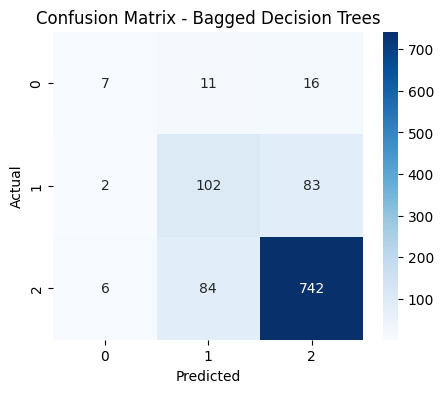

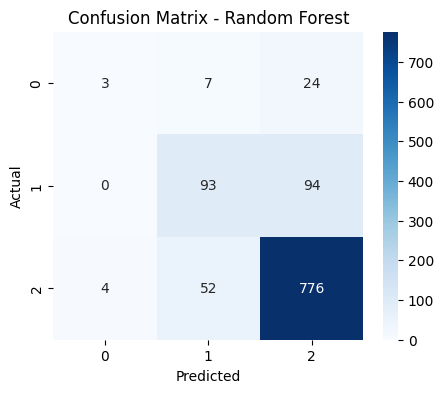

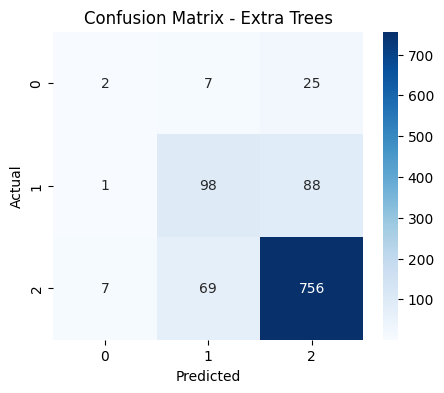

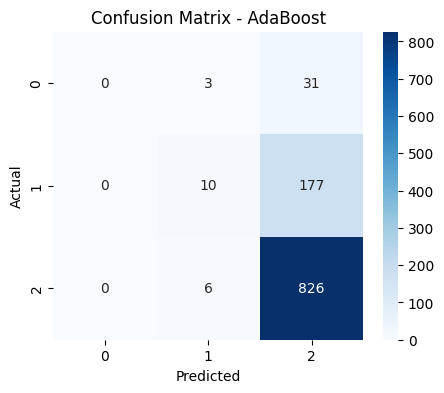

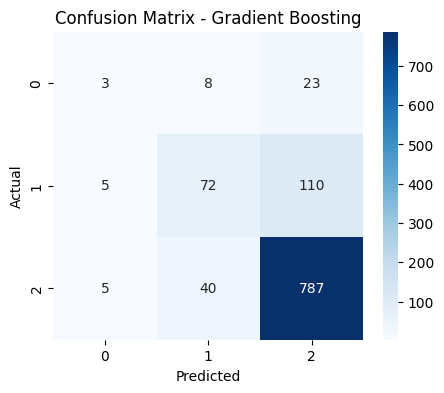

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


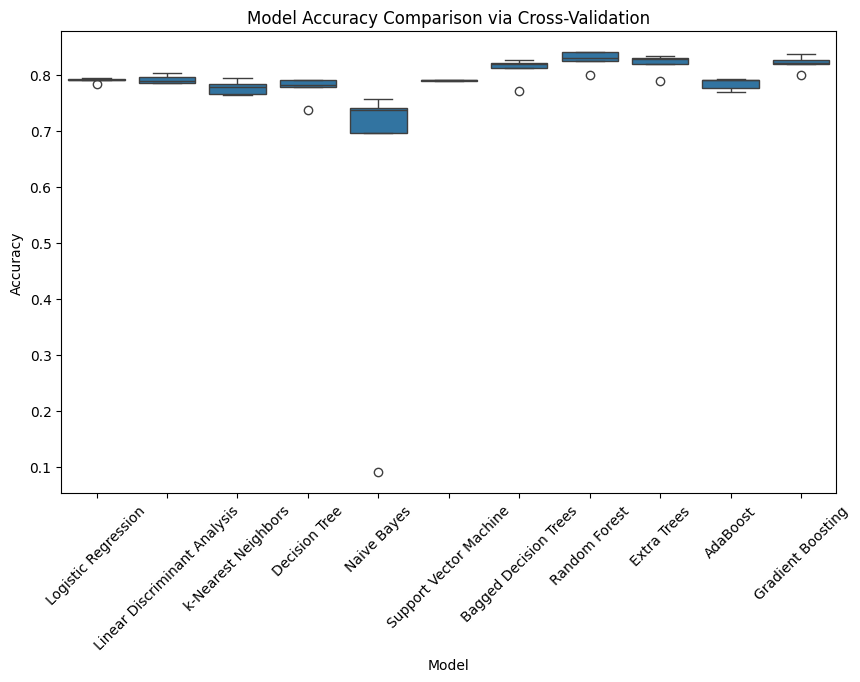

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Load the preprocessed dataset
data_final = pd.read_csv('/content/preprocessed_apartment_data.csv')

# Define target and features
X = data_final.drop('rent_category_encoded', axis=1)  # Assuming 'rent_category_encoded' is the target
y = data_final['rent_category_encoded']

# Split the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Models for comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),  # Increased max_iter to ensure convergence
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "k-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(),
    "Bagged Decision Trees": BaggingClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Comparative results storage
results = []

# Evaluate models and store results
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Create a DataFrame for comparative results
results_df = pd.DataFrame(results)

# Display tabulated results neatly
print("Comparative Analysis Results")
print(results_df.sort_values(by="Accuracy", ascending=False).to_string(index=False))

# Plot confusion matrices for each model
for name, model in models.items():
    y_pred = model.predict(X_test)
    conf_matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Boxplot of cross-validation scores
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    for score in scores:
        cv_results.append({"Model": name, "Accuracy": score})

cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="Accuracy", data=cv_df)
plt.title("Model Accuracy Comparison via Cross-Validation")
plt.xticks(rotation=45)
plt.show()
